# Dataset Exploration

This notebook contains comprehensive exploration and analysis of the binary classification dataset.


## 1. Import Libraries and Load Data


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Set plotting style
plt.style.use("default")
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load datasets
train_path = Path("data/train.csv")
test_path = Path("data/test_data.csv")

print("Loading datasets...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nDatasets loaded successfully!")

Loading datasets...
Training data shape: (10853, 44)
Test data shape: (2713, 43)

Datasets loaded successfully!


## 2. Dataset Structure Examination


In [4]:
# Identify feature types
numerical_cols = [col for col in train_df.columns if col.startswith("Num_")]
categorical_cols = [col for col in train_df.columns if col.startswith("Nom_")]
target_col = "Target (Col44)"

print("=" * 60)
print("DATASET STRUCTURE OVERVIEW")
print("=" * 60)

print(f"\nTraining Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape: {test_df.shape}")

print(f"\nMemory Usage:")
print(f"Training: {train_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Test: {test_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nFeature Distribution:")
print(f"Numerical Features: {len(numerical_cols)} (Num_Col1 to Num_Col25)")
print(f"Categorical Features: {len(categorical_cols)} (Nom_Col26 to Nom_Col43)")
print(f"Target Variable: {target_col}")

print(f"\nData Types (Training):")
print(train_df.dtypes.value_counts())

DATASET STRUCTURE OVERVIEW

Training Dataset Shape: (10853, 44)
Test Dataset Shape: (2713, 43)

Memory Usage:
Training: 13.22 MB
Test: 3.43 MB

Feature Distribution:
Numerical Features: 25 (Num_Col1 to Num_Col25)
Categorical Features: 18 (Nom_Col26 to Nom_Col43)
Target Variable: Target (Col44)

Data Types (Training):
float64    25
object     18
int64       1
Name: count, dtype: int64


In [5]:
# Display first few rows
print("First 5 rows of training data:")
display(train_df.head())

print("\nFirst 5 rows of test data:")
display(test_df.head())

First 5 rows of training data:


,Num_Col1,Num_Col2,Num_Col3,Num_Col4,Num_Col5,Num_Col6,Num_Col7,Num_Col8,Num_Col9,Num_Col10,Num_Col11,Num_Col12,Num_Col13,Num_Col14,Num_Col15,Num_Col16,Num_Col17,Num_Col18,Num_Col19,Num_Col20,Num_Col21,Num_Col22,Num_Col23,Num_Col24,Num_Col25,Nom_Col26,Nom_Col27,Nom_Col28,Nom_Col29,Nom_Col30,Nom_Col31,Nom_Col32,Nom_Col33,Nom_Col34,Nom_Col35,Nom_Col36,Nom_Col37,Nom_Col38,Nom_Col39,Nom_Col40,Nom_Col41,Nom_Col42,Nom_Col43,Target (Col44)
0,0.033869,0.001056,-9.926405,0.070394,0.000788,0.000097,-0.059231,0.000739,15.473141,NaN,NaN,-1.110999,NaN,0.055359,-0.095709,0.010123,0.000513,-0.001086,-3.222770,2.018805,-9.805278,-0.001650,-0.921850,-3.424253,-5.592108,C0_c0,C1_c0,C2_c0,C3_c0,C4_c0,C5_c0,C6_c0,C7_c0,C8_c0,C9_c0,C10_c0,C11_c0,C12_c0,C13_c0,C14_c0,C15_c0,C16_c0,C17_c0,1
1,0.053218,NaN,-0.038132,0.002473,0.000337,0.000445,0.022612,-0.000392,0.849532,-0.000488,-0.001933,11.554639,-0.001282,-0.032028,-0.128631,-0.001469,0.000403,0.000535,0.629298,-4.636672,8.646503,-0.000876,-8.051822,-11.816909,13.086544,C0_c0,C1_c1,C2_c1,C3_c1,C4_c1,C5_c0,C6_c0,C7_c0,C8_c1,C9_c1,C10_c1,C11_c0,C12_c0,C13_c1,C14_c1,C15_c1,C16_c1,C17_c1,0
2,NaN,0.001407,-0.018618,0.057979,NaN,0.000777,0.034021,NaN,-17.116814,0.000838,NaN,-8.222674,0.003000,0.200053,0.012449,-0.003797,-0.000538,-0.001175,6.383601,NaN,-1.050433,-0.000050,-18.995923,16.562392,8.902188,C0_c1,C1_c2,C2_c0,NaN,C4_c2,C5_c0,C6_c1,NaN,C8_c2,NaN,C10_c2,NaN,C12_c1,NaN,NaN,C15_c1,C16_c2,C17_c2,0
3,0.038971,0.012082,0.038099,0.053880,0.000995,0.000308,0.072476,0.001358,-14.968760,0.002161,0.003810,-1.047776,-0.000636,-0.121213,-0.100201,-0.004904,-0.000584,-0.000959,8.021526,4.750045,-14.086352,0.001427,13.265513,13.539776,8.616310,C0_c0,C1_c3,C2_c1,C3_c2,C4_c1,C5_c0,NaN,C7_c0,NaN,C9_c0,C10_c3,C11_c2,C12_c1,C13_c0,C14_c1,C15_c2,C16_c2,C17_c3,0
4,0.000503,0.011750,-0.019909,0.054219,0.000177,-0.000018,-0.012990,-0.001080,15.014805,-0.000160,NaN,-2.809441,-0.003370,-0.015419,-0.122744,-0.003576,0.000029,-0.000101,NaN,-12.811490,7.139776,0.000103,3.836784,1.481279,17.023131,C0_c0,C1_c4,C2_c2,C3_c1,C4_c3,C5_c0,C6_c0,C7_c0,C8_c4,C9_c1,C10_c4,C11_c1,C12_c2,NaN,C14_c3,C15_c1,C16_c1,C17_c4,0



First 5 rows of test data:


,Num_Col1,Num_Col2,Num_Col3,Num_Col4,Num_Col5,Num_Col6,Num_Col7,Num_Col8,Num_Col9,Num_Col10,Num_Col11,Num_Col12,Num_Col13,Num_Col14,Num_Col15,Num_Col16,Num_Col17,Num_Col18,Num_Col19,Num_Col20,Num_Col21,Num_Col22,Num_Col23,Num_Col24,Num_Col25,Nom_Col26,Nom_Col27,Nom_Col28,Nom_Col29,Nom_Col30,Nom_Col31,Nom_Col32,Nom_Col33,Nom_Col34,Nom_Col35,Nom_Col36,Nom_Col37,Nom_Col38,Nom_Col39,Nom_Col40,Nom_Col41,Nom_Col42,Nom_Col43
0,0.020548,0.004069,-0.002003,-0.003088,0.000398,0.000097,0.093029,0.001299,2.037374,-0.000325,-0.022753,7.198142,-0.007082,0.102008,-0.016424,0.026139,0.000388,0.000371,-0.280177,5.786565,9.783606,0.000641,-5.009260,-20.281379,-4.395846,C0_c0,C1_c7,C2_c1,C3_c4,C4_c1,C5_c0,C6_c0,C7_c0,C8_c0,C9_c1,C10_c2,C11_c8,C12_c5,C13_c4,C14_c2,C15_c4,C16_c0,C17_c0
1,0.043836,0.003238,0.006178,0.004307,0.000378,0.000445,-0.081911,-0.000169,2.648204,-0.000592,-0.013285,-5.228457,-0.003324,-0.077878,0.002895,0.021793,0.001165,-0.000505,-4.082203,15.972935,1.002138,-0.001255,-2.920942,14.894845,-13.209657,C0_c0,C1_c3,C2_c1,C3_c5,C4_c1,C5_c4,C6_c0,C7_c0,C8_c2,C9_c3,C10_c4,C11_c8,C12_c5,C13_c0,C14_c0,C15_c2,C16_c1,C17_c1
2,0.075342,0.001684,-0.013178,0.003124,0.000153,0.000777,-0.007749,-0.001433,-14.220140,0.000226,0.020617,-3.562082,0.012264,0.073931,0.018636,-0.017940,-0.000566,0.001169,-7.230245,-7.632760,-9.018198,-0.000723,-5.268160,3.592849,0.668866,C0_c0,C1_c6,C2_c3,C3_c3,C4_c2,C5_c0,C6_c1,C7_c0,C8_c5,C9_c1,C10_c3,C11_c5,C12_c5,C13_c2,C14_c4,C15_c0,C16_c2,C17_c5
3,0.006849,0.010447,0.025087,-0.002061,0.000398,0.000308,0.063634,0.000361,11.378327,0.000340,0.003791,10.696173,-0.005836,-0.039173,0.034926,-0.006214,0.000979,-0.001547,-3.740309,-15.984730,-22.107989,0.000277,-14.261719,1.721874,4.892540,C0_c0,C1_c6,C2_c2,C3_c3,C4_c0,C5_c0,C6_c1,C7_c0,C8_c7,C9_c1,C10_c6,C11_c7,C12_c5,C13_c4,C14_c7,C15_c2,C16_c0,C17_c0
4,0.023288,0.012557,-0.004602,-0.011326,0.000398,-0.000018,-0.127465,0.000469,-8.528043,0.000725,-0.006205,-10.425254,0.016343,-0.156937,0.152063,0.000738,0.000988,-0.000085,-1.420751,5.198068,-16.778333,-0.000738,-24.528777,-10.628967,0.718718,C0_c1,C1_c1,C2_c0,C3_c12,C4_c2,C5_c2,C6_c1,C7_c0,C8_c0,C9_c0,C10_c2,C11_c3,C12_c5,C13_c1,C14_c2,C15_c0,C16_c1,C17_c2


In [6]:
# Feature consistency check
train_features = set(train_df.columns) - {target_col}
test_features = set(test_df.columns)

print("Feature Consistency Check:")
print(f"Features in train but not test: {train_features - test_features}")
print(f"Features in test but not train: {test_features - train_features}")
print(f"Common features: {len(train_features & test_features)}")
print("✓ All features are consistent between train and test sets")

Feature Consistency Check:
Features in train but not test: set()
Features in test but not train: set()
Common features: 43
✓ All features are consistent between train and test sets


## 3. Statistical Analysis of Numerical Features


In [7]:
print("=" * 60)
print("NUMERICAL FEATURES STATISTICAL ANALYSIS")
print("=" * 60)

# Descriptive statistics for numerical features
print("\nDescriptive Statistics for Numerical Features:")
numerical_stats = train_df[numerical_cols].describe()
display(numerical_stats)

NUMERICAL FEATURES STATISTICAL ANALYSIS

Descriptive Statistics for Numerical Features:


,Num_Col1,Num_Col2,Num_Col3,Num_Col4,Num_Col5,Num_Col6,Num_Col7,Num_Col8,Num_Col9,Num_Col10,Num_Col11,Num_Col12,Num_Col13,Num_Col14,Num_Col15,Num_Col16,Num_Col17,Num_Col18,Num_Col19,Num_Col20,Num_Col21,Num_Col22,Num_Col23,Num_Col24,Num_Col25
count,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9768.000000,9.768000e+03,9768.000000,9768.000000,9768.000000,9768.000000,9.768000e+03,9768.000000,9768.000000,9768.000000
mean,0.029562,0.011932,-0.114095,-0.201962,0.000407,-0.000004,-0.001321,-0.000002,-0.026534,0.000007,0.000019,-0.117850,-0.000180,-0.000777,-0.000882,0.000184,-6.092210e-09,0.000003,0.048619,-0.023529,0.074605,4.709995e-07,-0.011139,0.091275,-0.064024
std,0.018302,0.007123,0.777991,0.925610,0.000123,0.000993,0.100835,0.000993,10.089639,0.001011,0.009906,9.884575,0.010008,0.100511,0.100153,0.010094,1.003829e-03,0.000990,9.931712,10.056757,9.974422,9.942902e-04,9.982573,10.043132,9.879577
min,-0.007180,-0.001422,-10.170918,-8.635131,-0.000009,-0.004342,-0.373079,-0.003680,-36.768642,-0.003837,-0.037682,-36.195192,-0.035656,-0.360511,-0.376567,-0.036085,-4.133633e-03,-0.004181,-35.953217,-41.294619,-43.274390,-4.030400e-03,-37.699793,-40.606047,-34.288045
25%,0.015220,0.007011,-0.067550,-0.073861,0.000380,-0.000670,-0.068866,-0.000664,-6.828499,-0.000667,-0.006748,-6.739393,-0.006921,-0.067492,-0.068996,-0.006585,-6.640254e-04,-0.000674,-6.657168,-6.639188,-6.581906,-6.602990e-04,-6.830285,-6.759379,-6.723944
50%,0.027563,0.011149,-0.009784,-0.006601,0.000400,-0.000017,-0.001261,-0.000004,-0.057933,0.000006,-0.000005,-0.117669,-0.000240,-0.001935,-0.000684,0.000362,-7.190941e-07,0.000008,0.011887,-0.063011,0.071125,-2.287133e-06,0.022205,0.110396,-0.049094
75%,0.041695,0.015232,0.044686,0.057501,0.000454,0.000663,0.067385,0.000672,6.798960,0.000679,0.006831,6.645229,0.006570,0.065484,0.066981,0.006952,6.893536e-04,0.000683,6.757489,6.828271,6.711849,6.710959e-04,6.843720,6.801672,6.447034
max,0.103033,0.100714,0.301574,0.343910,0.001026,0.003808,0.435456,0.003730,36.258796,0.004252,0.042153,41.396171,0.034104,0.382535,0.374851,0.038684,4.146123e-03,0.003765,35.204866,35.401661,37.361958,3.382121e-03,34.033876,38.408416,42.190855


In [9]:
# Range analysis
print("\nRange Analysis (Min-Max spread):")
range_analysis = pd.DataFrame(
    {
        "Min": train_df[numerical_cols].min(),
        "Max": train_df[numerical_cols].max(),
        "Range": train_df[numerical_cols].max() - train_df[numerical_cols].min(),
        "IQR": train_df[numerical_cols].quantile(0.75)
        - train_df[numerical_cols].quantile(0.25),
    }
)

display(range_analysis.head(10))
print("\n... (showing first 10 features)")


Range Analysis (Min-Max spread):


,Min,Max,Range,IQR
Num_Col1,-0.007180,0.103033,0.110213,0.026475
Num_Col2,-0.001422,0.100714,0.102135,0.008222
Num_Col3,-10.170918,0.301574,10.472492,0.112236
Num_Col4,-8.635131,0.343910,8.979042,0.131362
Num_Col5,-0.000009,0.001026,0.001035,0.000074
Num_Col6,-0.004342,0.003808,0.008150,0.001333
Num_Col7,-0.373079,0.435456,0.808536,0.136251
Num_Col8,-0.003680,0.003730,0.007409,0.001336
Num_Col9,-36.768642,36.258796,73.027438,13.627459
Num_Col10,-0.003837,0.004252,0.008089,0.001346



... (showing first 10 features)


## 4. Missing Value Analysis


In [16]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

# Overall missing value summary
total_cells = np.prod(train_df.shape)
total_missing = train_df.isnull().sum().sum()
missing_percentage = (total_missing / total_cells) * 100

print(f"\nOverall Missing Value Summary:")
print(f"Total cells: {total_cells:,}")
print(f"Total missing values: {total_missing:,}")
print(f"Overall missing percentage: {missing_percentage:.2f}%")

MISSING VALUE ANALYSIS

Overall Missing Value Summary:
Total cells: 477,532
Total missing values: 46,655
Overall missing percentage: 9.77%


In [17]:
# Missing values by feature type
print("\nMissing Values by Feature Type:")

# Numerical features
num_missing = train_df[numerical_cols].isnull().sum()
print(f"\nNumerical features with missing values:")
num_missing_sorted = num_missing[num_missing > 0].sort_values(ascending=False)
print(
    f"Features with missing values: {len(num_missing_sorted)} out of {len(numerical_cols)}"
)
if len(num_missing_sorted) > 0:
    display(
        pd.DataFrame(
            {
                "Missing_Count": num_missing_sorted,
                "Missing_Percentage": (num_missing_sorted / len(train_df) * 100).round(
                    2
                ),
            }
        ).head(10)
    )


Missing Values by Feature Type:

Numerical features with missing values:
Features with missing values: 25 out of 25


,Missing_Count,Missing_Percentage
Num_Col1,1085,10.0
Num_Col2,1085,10.0
Num_Col3,1085,10.0
Num_Col4,1085,10.0
Num_Col5,1085,10.0
Num_Col6,1085,10.0
Num_Col7,1085,10.0
Num_Col8,1085,10.0
Num_Col9,1085,10.0
Num_Col10,1085,10.0


In [18]:
# Categorical features
cat_missing = train_df[categorical_cols].isnull().sum()
print(f"\nCategorical features with missing values:")
cat_missing_sorted = cat_missing[cat_missing > 0].sort_values(ascending=False)
print(
    f"Features with missing values: {len(cat_missing_sorted)} out of {len(categorical_cols)}"
)
if len(cat_missing_sorted) > 0:
    display(
        pd.DataFrame(
            {
                "Missing_Count": cat_missing_sorted,
                "Missing_Percentage": (cat_missing_sorted / len(train_df) * 100).round(
                    2
                ),
            }
        ).head(10)
    )


Categorical features with missing values:
Features with missing values: 18 out of 18


,Missing_Count,Missing_Percentage
Nom_Col26,1085,10.0
Nom_Col27,1085,10.0
Nom_Col28,1085,10.0
Nom_Col29,1085,10.0
Nom_Col30,1085,10.0
Nom_Col31,1085,10.0
Nom_Col32,1085,10.0
Nom_Col33,1085,10.0
Nom_Col34,1085,10.0
Nom_Col35,1085,10.0


## 5. Target Variable Analysis


In [19]:
print("=" * 60)
print("TARGET VARIABLE ANALYSIS")
print("=" * 60)

# Target variable distribution
target_dist = train_df[target_col].value_counts()
target_pct = train_df[target_col].value_counts(normalize=True) * 100

print(f"\nTarget Variable Distribution:")
target_summary = pd.DataFrame({"Count": target_dist, "Percentage": target_pct.round(2)})
display(target_summary)

print(f"\nClass Balance Analysis:")
class_ratio = target_dist.max() / target_dist.min()
print(f"Class ratio (majority/minority): {class_ratio:.2f}")
if class_ratio > 1.5:
    print("⚠️  Dataset shows class imbalance")
else:
    print("✓ Dataset is relatively balanced")

TARGET VARIABLE ANALYSIS

Target Variable Distribution:


,Count,Percentage
Target (Col44),,
0,8170,75.28
1,2683,24.72



Class Balance Analysis:
Class ratio (majority/minority): 3.05
⚠️  Dataset shows class imbalance


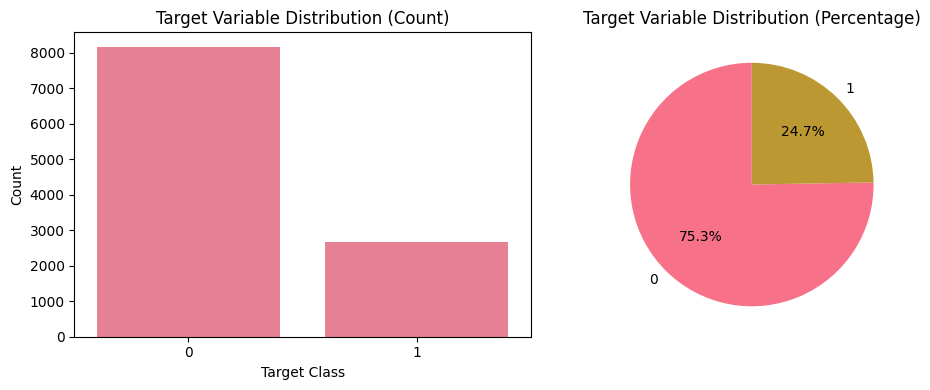

In [20]:
# Visualize target distribution
plt.figure(figsize=(10, 4))

# Count plot
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x=target_col)
plt.title("Target Variable Distribution (Count)")
plt.xlabel("Target Class")
plt.ylabel("Count")

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(target_dist.values, labels=target_dist.index, autopct="%1.1f%%", startangle=90)
plt.title("Target Variable Distribution (Percentage)")

plt.tight_layout()
plt.show()

## 6. Categorical Feature Exploration


In [21]:
print("=" * 60)
print("CATEGORICAL FEATURES EXPLORATION")
print("=" * 60)

# Analyze categorical features
cat_analysis = []
for col in categorical_cols:
    unique_vals = train_df[col].nunique()
    missing_vals = train_df[col].isnull().sum()
    missing_pct = (missing_vals / len(train_df)) * 100
    most_frequent = (
        train_df[col].mode().iloc[0] if len(train_df[col].mode()) > 0 else "NaN"
    )

    cat_analysis.append(
        {
            "Feature": col,
            "Unique_Values": unique_vals,
            "Missing_Count": missing_vals,
            "Missing_Pct": round(missing_pct, 2),
            "Most_Frequent": most_frequent,
        }
    )

cat_df = pd.DataFrame(cat_analysis)
print("\nCategorical Features Summary:")
display(cat_df.head(10))
print("\n... (showing first 10 features)")

CATEGORICAL FEATURES EXPLORATION

Categorical Features Summary:


,Feature,Unique_Values,Missing_Count,Missing_Pct,Most_Frequent
0,Nom_Col26,7,1085,10.0,C0_c0
1,Nom_Col27,16,1085,10.0,C1_c6
2,Nom_Col28,7,1085,10.0,C2_c1
3,Nom_Col29,14,1085,10.0,C3_c1
4,Nom_Col30,6,1085,10.0,C4_c1
5,Nom_Col31,5,1085,10.0,C5_c0
6,Nom_Col32,2,1085,10.0,C6_c0
7,Nom_Col33,40,1085,10.0,C7_c0
8,Nom_Col34,9,1085,10.0,C8_c3
9,Nom_Col35,4,1085,10.0,C9_c3



... (showing first 10 features)


In [22]:
# Sample categorical value patterns
print("\nSample Categorical Value Patterns:")
sample_cols = categorical_cols[:5]
for col in sample_cols:
    print(f"\n{col}:")
    value_counts = train_df[col].value_counts().head()
    print(value_counts)


Sample Categorical Value Patterns:

Nom_Col26:
Nom_Col26
C0_c0    7186
C0_c3     839
C0_c1     654
C0_c5     420
C0_c2     339
Name: count, dtype: int64

Nom_Col27:
Nom_Col27
C1_c6     3100
C1_c1     2163
C1_c10    1667
C1_c2      539
C1_c7      469
Name: count, dtype: int64

Nom_Col28:
Nom_Col28
C2_c1    4499
C2_c2    3164
C2_c0    1370
C2_c4     342
C2_c3     278
Name: count, dtype: int64

Nom_Col29:
Nom_Col29
C3_c1    1331
C3_c0    1292
C3_c4    1280
C3_c6    1209
C3_c9    1168
Name: count, dtype: int64

Nom_Col30:
Nom_Col30
C4_c1    3975
C4_c0    2590
C4_c3    1465
C4_c2    1015
C4_c5     442
Name: count, dtype: int64


## 7. Data Visualization


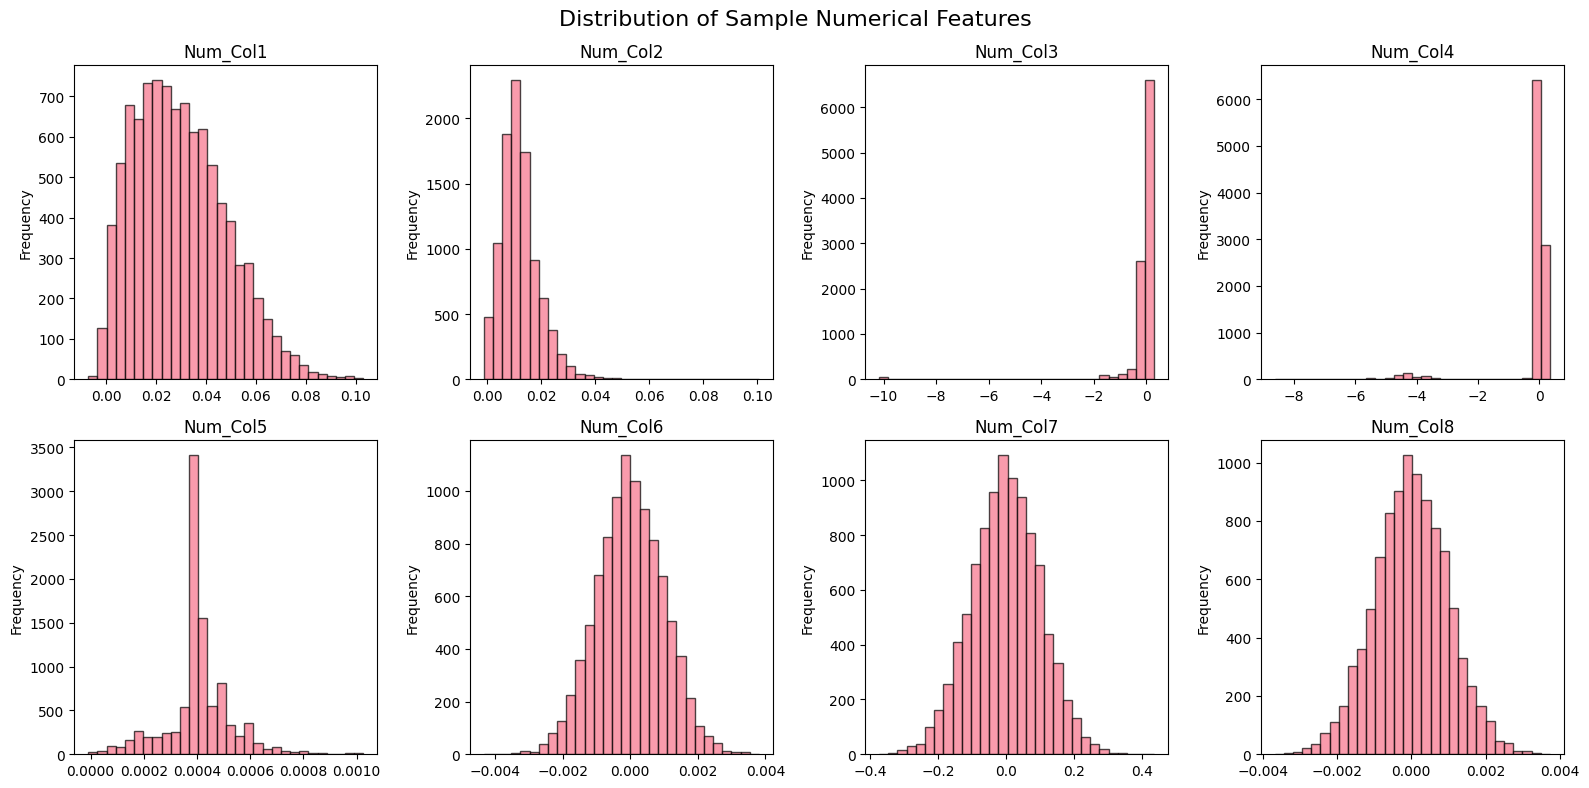

In [23]:
# Distribution of numerical features (sample)
sample_num_cols = numerical_cols[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Distribution of Sample Numerical Features", fontsize=16)

for i, col in enumerate(sample_num_cols):
    row = i // 4
    col_idx = i % 4

    # Remove missing values for plotting
    data = train_df[col].dropna()

    axes[row, col_idx].hist(data, bins=30, alpha=0.7, edgecolor="black")
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

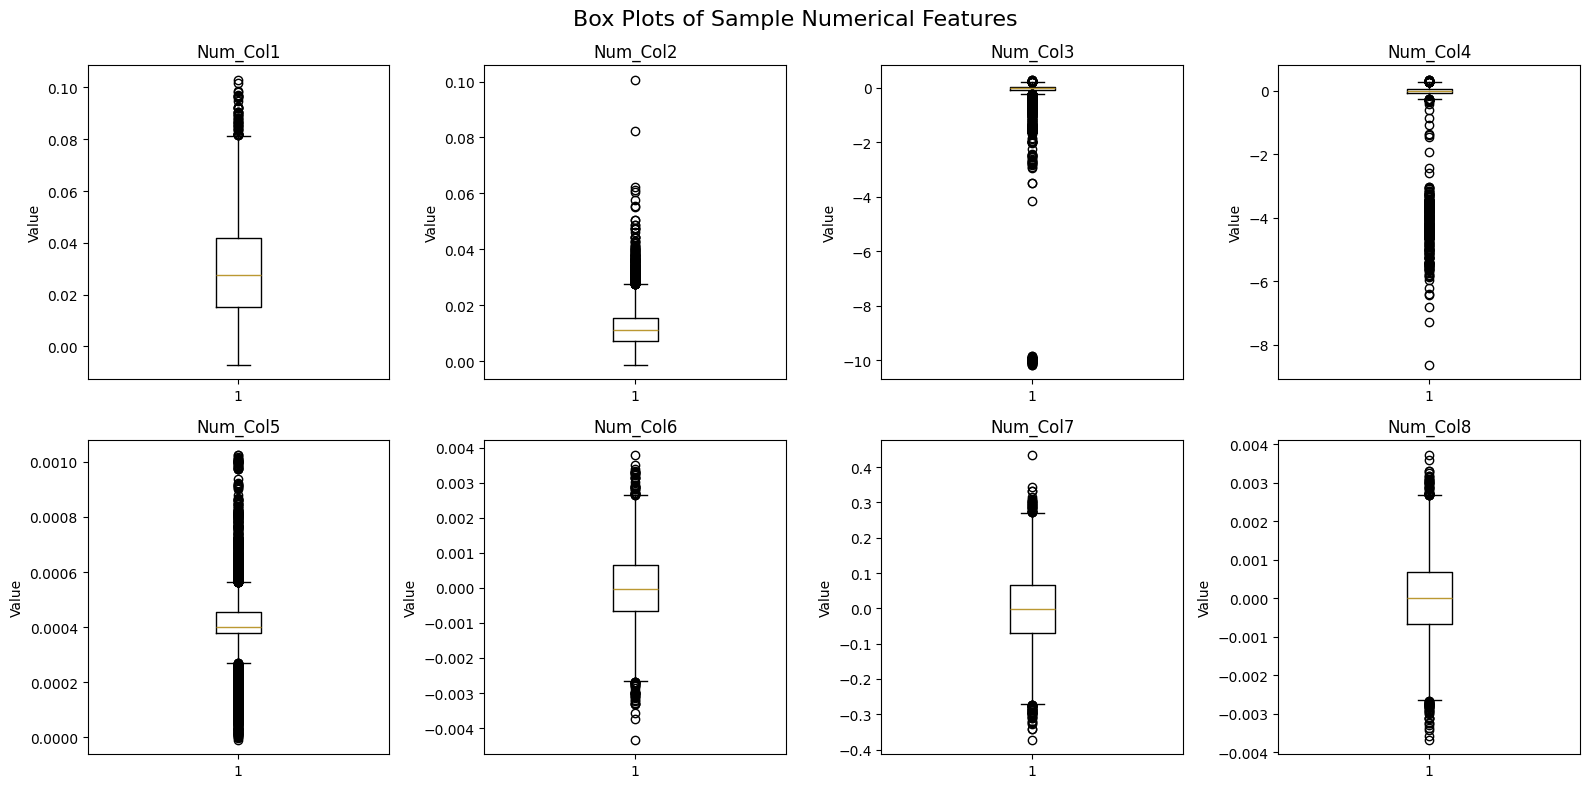

In [24]:
# Box plots for numerical features (sample)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Box Plots of Sample Numerical Features", fontsize=16)

for i, col in enumerate(sample_num_cols):
    row = i // 4
    col_idx = i % 4

    # Remove missing values for plotting
    data = train_df[col].dropna()

    axes[row, col_idx].boxplot(data)
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel("Value")

plt.tight_layout()
plt.show()

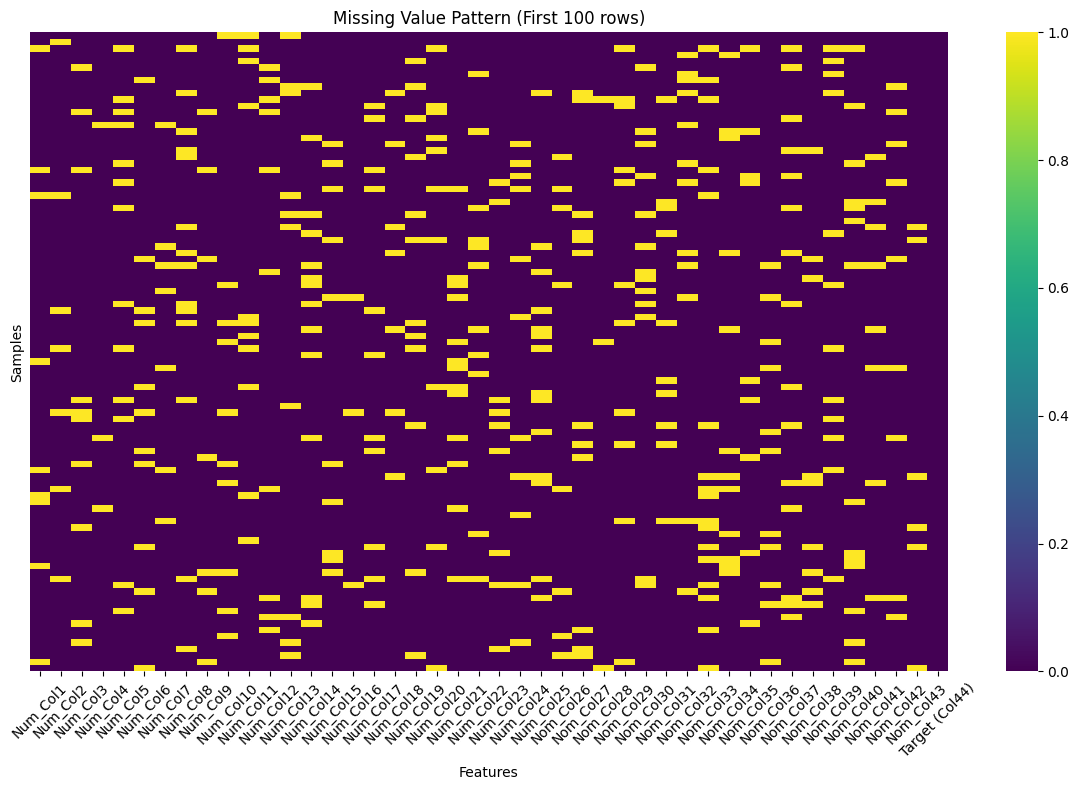

In [25]:
# Missing value heatmap
plt.figure(figsize=(12, 8))
missing_data = train_df.isnull()
sns.heatmap(missing_data.iloc[:100, :], cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing Value Pattern (First 100 rows)")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Summary and Key Findings


In [26]:
print("=" * 60)
print("DATASET EXPLORATION SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset Overview:")
print(f"   • Training samples: {train_df.shape[0]:,}")
print(f"   • Test samples: {test_df.shape[0]:,}")
print(f"   • Total features: {len(numerical_cols) + len(categorical_cols)}")
print(f"   • Numerical features: {len(numerical_cols)}")
print(f"   • Categorical features: {len(categorical_cols)}")

print(f"\n🎯 Target Variable:")
print(f"   • Type: Binary classification (0/1)")
print(f"   • Class distribution: {dict(target_dist)}")
print(f"   • Balance ratio: {class_ratio:.2f}")

print(f"\n❌ Missing Values:")
print(f"   • Overall missing: {missing_percentage:.2f}%")
print(
    f"   • Numerical features affected: {len(num_missing_sorted)} / {len(numerical_cols)}"
)
print(
    f"   • Categorical features affected: {len(cat_missing_sorted)} / {len(categorical_cols)}"
)

print(f"\n🔢 Numerical Features:")
print(f"   • Range varies significantly across features")
print(f"   • Mix of small decimals and larger integers")
print(f"   • Some features show high skewness")

print(f"\n📝 Categorical Features:")
print(f"   • Encoded format: C{{category}}_c{{value}}")
print(f"   • Variable cardinality across features")
print(f"   • Consistent encoding scheme")

print(f"\n⚠️  Key Challenges:")
print(f"   • Extensive missing values requiring imputation")
print(f"   • Feature scaling needed for numerical variables")
print(f"   • Categorical encoding strategy required")
if class_ratio > 1.5:
    print(f"   • Class imbalance may need addressing")

print(f"\n✅ Next Steps:")
print(f"   • Develop missing value imputation strategy")
print(f"   • Plan feature scaling approach")
print(f"   • Design categorical encoding method")
print(f"   • Consider feature engineering opportunities")
print(f"   • Select appropriate evaluation metrics")

DATASET EXPLORATION SUMMARY

📊 Dataset Overview:
   • Training samples: 10,853
   • Test samples: 2,713
   • Total features: 43
   • Numerical features: 25
   • Categorical features: 18

🎯 Target Variable:
   • Type: Binary classification (0/1)
   • Class distribution: {0: np.int64(8170), 1: np.int64(2683)}
   • Balance ratio: 3.05

❌ Missing Values:
   • Overall missing: 9.77%
   • Numerical features affected: 25 / 25
   • Categorical features affected: 18 / 18

🔢 Numerical Features:
   • Range varies significantly across features
   • Mix of small decimals and larger integers
   • Some features show high skewness

📝 Categorical Features:
   • Encoded format: C{category}_c{value}
   • Variable cardinality across features
   • Consistent encoding scheme

⚠️  Key Challenges:
   • Extensive missing values requiring imputation
   • Feature scaling needed for numerical variables
   • Categorical encoding strategy required
   • Class imbalance may need addressing

✅ Next Steps:
   • Develop